# Lab Segmentation 2

In [120]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [121]:
# SAFE convert to uint8
def convert_to_uint8(image):
    if image.dtype == np.uint8:
        return image
    if image.max() <= 1.0:
        return (image * 255).astype(np.uint8)
    return image.astype(np.uint8)

# Histogram
def get_counts_array(image):
    counts = np.zeros(256, dtype=int)
    for pixel in image.flatten():
        counts[pixel] += 1
    return counts

# Initial threshold = global mean
def get_initial_threshold(counts):
    total_pixels = np.sum(counts)
    weighted_sum = sum(i * counts[i] for i in range(256))
    return round(weighted_sum / total_pixels)

# Weighted means
def get_weighted_averages(counts, T):
    lower_sum = sum(i * counts[i] for i in range(T))
    lower_count = sum(counts[i] for i in range(T))

    upper_sum = sum(i * counts[i] for i in range(T, 256))
    upper_count = sum(counts[i] for i in range(T, 256))

    mean_lower = lower_sum / lower_count if lower_count > 0 else 0
    mean_upper = upper_sum / upper_count if upper_count > 0 else 0

    return mean_lower, mean_upper

# Iteration
def iterative_thresholding(counts, T_init):
    T_new = T_init
    while True:
        m_low, m_up = get_weighted_averages(counts, T_new)
        T_updated = round((m_low + m_up) / 2)
        if T_updated == T_new:
            break
        T_new = T_updated
    return T_new

# MAIN FUNCTION 
def getThreshold(image):
    image_u8 = convert_to_uint8(image)
    counts = get_counts_array(image_u8)
    T_init = get_initial_threshold(counts)
    return iterative_thresholding(counts, T_init)

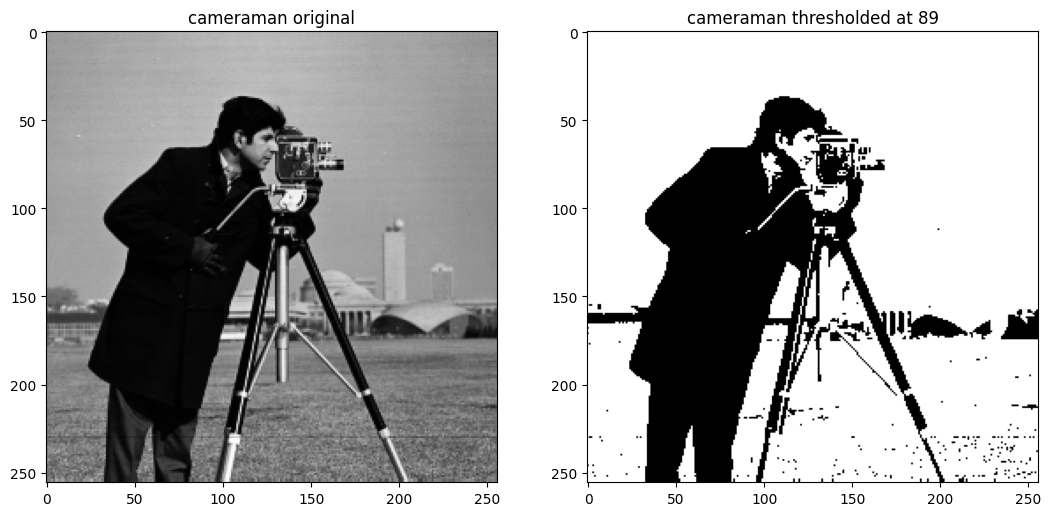

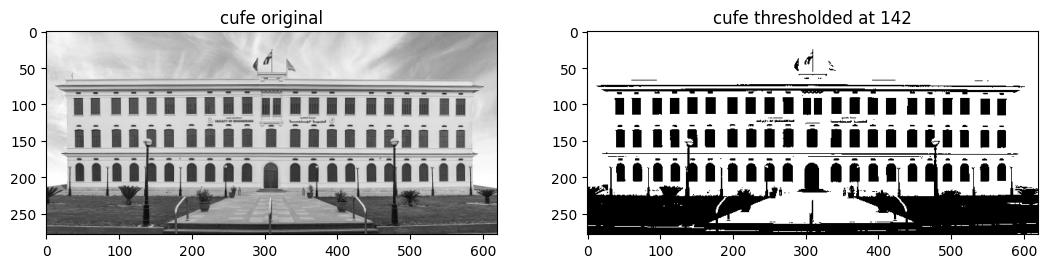

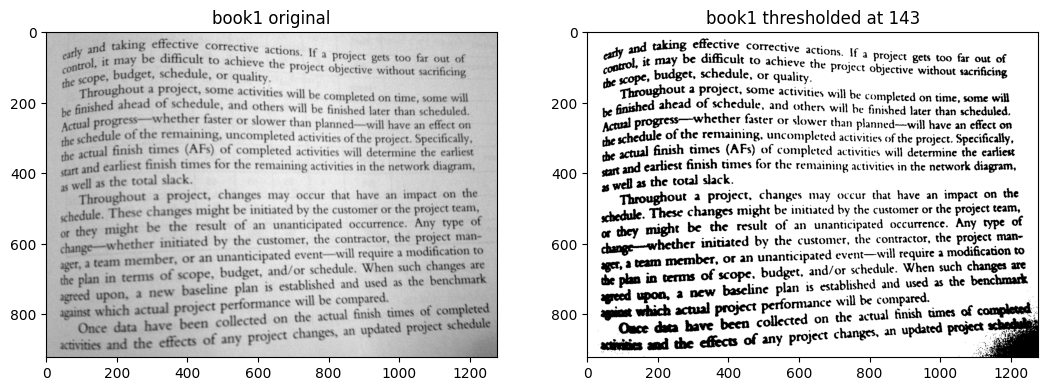

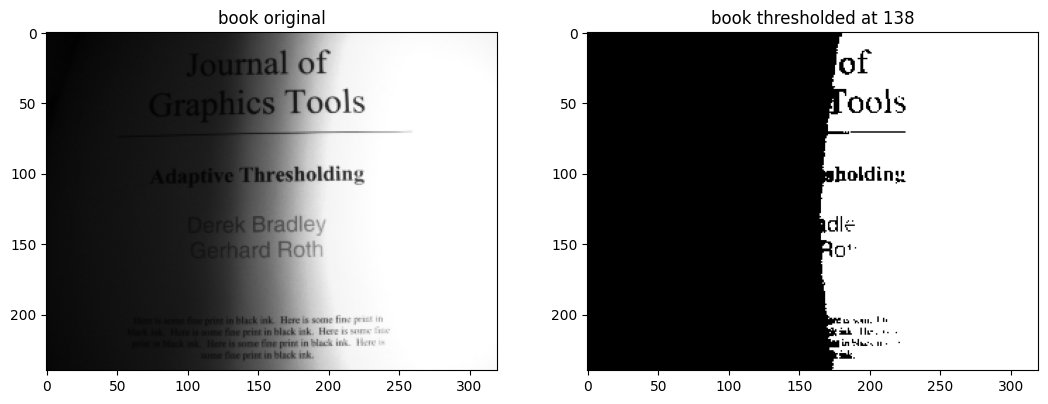

In [122]:
# Experiment 1: Test the thresholding on the specified images
images = ['cameraman', 'cufe', 'book1', 'book']

for img_name in images:
    img = io.imread(img_name + '.png', as_gray=True)
    threshold = getThreshold(img)
    img_u8 = convert_to_uint8(img)
    binary_img = (img_u8 >= threshold).astype(np.uint8) * 255
    show_images([img, binary_img], [f'{img_name} original', f'{img_name} thresholded at {threshold}'])

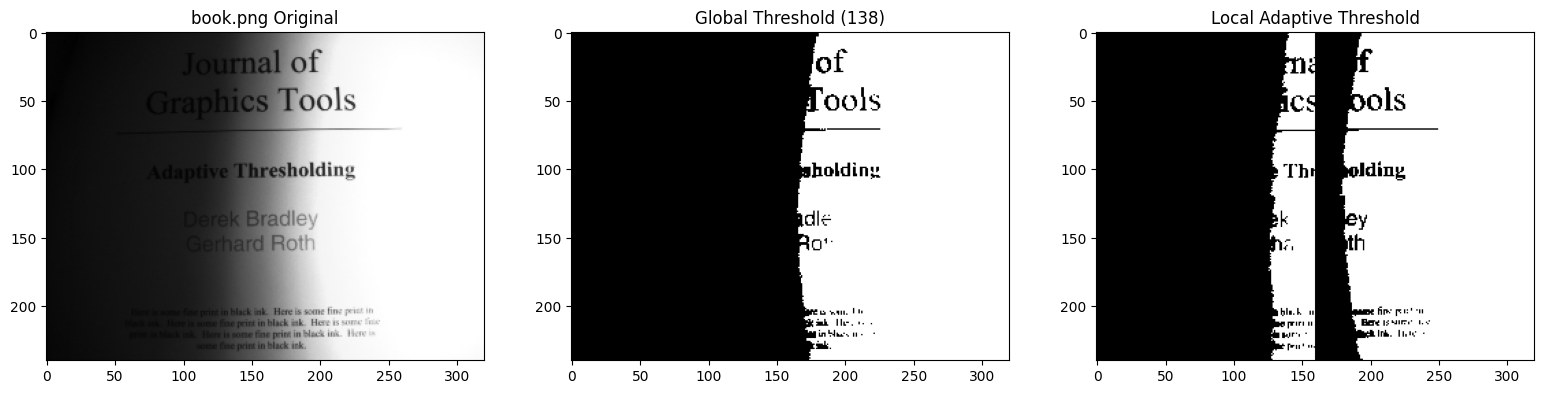

In [123]:
# Experiment 2: Local adaptive thresholding on "book.png"
book_img = io.imread('book.png', as_gray=True)
book_img_u8 = convert_to_uint8(book_img)

# 1. Global thresholding
global_threshold = getThreshold(book_img)
global_binary = (book_img_u8 >= global_threshold).astype(np.uint8) * 255

# 2. Partition into four quarters
h, w = book_img.shape
h_half, w_half = h // 2, w // 2

quarters = [
    book_img[:h_half, :w_half],
    book_img[:h_half, w_half:],
    book_img[h_half:, :w_half],
    book_img[h_half:, w_half:]
]

# Apply local threshold on each quarter
local_binary_quarters = []
for quarter in quarters:
    local_thresh = getThreshold(quarter)
    quarter_u8 = convert_to_uint8(quarter)
    local_binary = (quarter_u8 >= local_thresh).astype(np.uint8) * 255
    local_binary_quarters.append(local_binary)

# 3. Gather the four quarters together
local_binary = np.zeros_like(book_img_u8, dtype=np.uint8)
local_binary[:h_half, :w_half] = local_binary_quarters[0]
local_binary[:h_half, w_half:] = local_binary_quarters[1]
local_binary[h_half:, :w_half] = local_binary_quarters[2]
local_binary[h_half:, w_half:] = local_binary_quarters[3]

show_images([book_img, global_binary, local_binary],
            ['book.png Original', f'Global Threshold ({global_threshold})', 'Local Adaptive Threshold'])

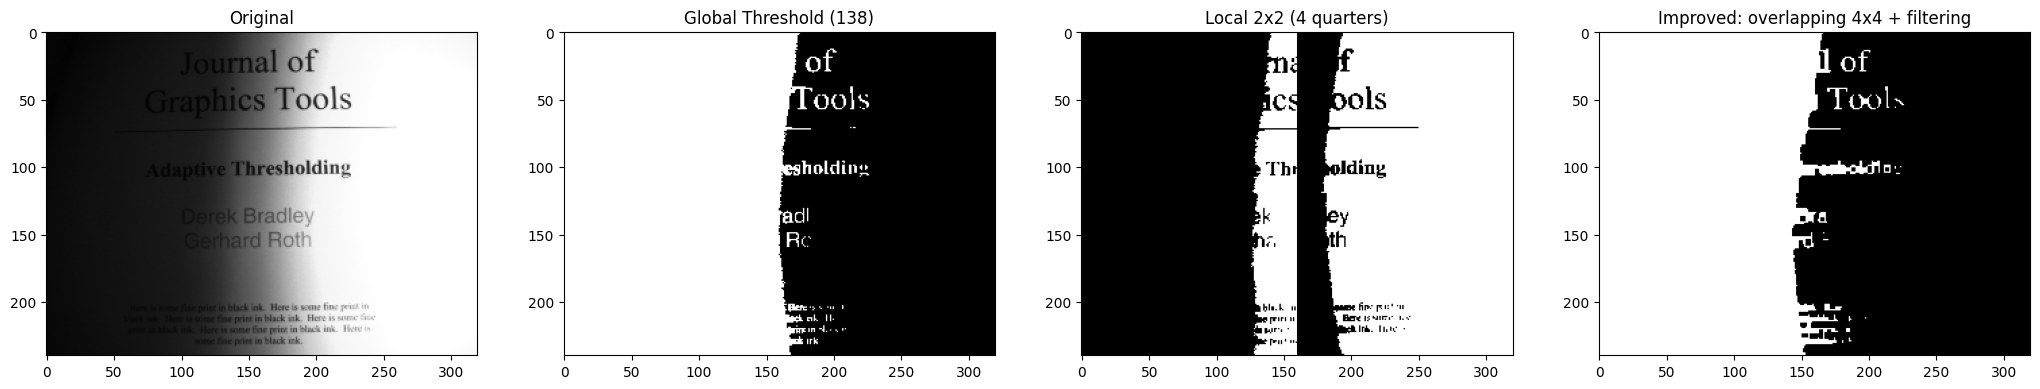

In [129]:
# Experiment 3 (Bonus): Improve segmentation with overlapping adaptive blocks + post-processing
from scipy.ndimage import median_filter
from skimage.morphology import binary_closing

# Reuse global threshold result
global_threshold = getThreshold(book_img)
global_binary = np.where(book_img * 255 < global_threshold, 0, 255).astype(np.uint8)

h, w = book_img.shape
rows, cols = 4, 4  # smaller blocks -> finer adaptation
block_h, block_w = h // rows, w // cols
overlap = 24  # pixels to overlap to avoid seams

accumulator = np.zeros((h, w), dtype=np.float64)
weights = np.zeros((h, w), dtype=np.float64)

for row in range(rows):
    for col in range(cols):
        r0 = max(0, row * block_h - overlap)
        r1 = min(h, (row + 1) * block_h + overlap)
        c0 = max(0, col * block_w - overlap)
        c1 = min(w, (col + 1) * block_w + overlap)

        block = book_img[r0:r1, c0:c1]
        if block.size == 0:
            continue

        block_thresh = getThreshold(block)
        block_binary = np.where(block * 255 < block_thresh, 0, 255).astype(np.float64)

        accumulator[r0:r1, c0:c1] += block_binary
        weights[r0:r1, c0:c1] += 1

# Averaging overlapping regions
improved_local_binary = np.where(weights > 0, accumulator / weights, 0)
improved_local_binary = (improved_local_binary >= 128).astype(np.uint8) * 255

# Closing
improved_local_binary = binary_closing((improved_local_binary == 255), footprint=np.ones((3, 3))).astype(np.uint8) * 255

show_images(
    [book_img, global_binary, local_binary, improved_local_binary],
    ['Original',f'Global Threshold ({global_threshold})','Local 2x2 (4 quarters)','Improved: overlapping 4x4 + filtering']
)